<a href="https://colab.research.google.com/github/tegga8/GEN_AI_Fundamentals/blob/main/CNN_CIFAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
model = models.Sequential([
    # 1st Conv
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    # 2nd Conv
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # 3rd Conv
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    # Flattening and densing
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 83ms/step - accuracy: 0.2294 - loss: 2.2857 - val_accuracy: 0.4182 - val_loss: 1.6285
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 98ms/step - accuracy: 0.4058 - loss: 1.6329 - val_accuracy: 0.4700 - val_loss: 1.4591
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 94ms/step - accuracy: 0.4879 - loss: 1.4423 - val_accuracy: 0.5439 - val_loss: 1.2793
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 104ms/step - accuracy: 0.5399 - loss: 1.3091 - val_accuracy: 0.5682 - val_loss: 1.2228
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - accuracy: 0.5699 - loss: 1.2163 - val_accuracy: 0.6037 - val_loss: 1.1466
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6019 - loss: 1.1369 - val_accuracy: 0.6327 - val_loss: 1.0662
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 86ms/step - accuracy: 0.6255 - loss: 1.0698 - val_accuracy: 0.6213 - val_loss: 1.0910
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.6454 - loss: 1.0121 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6566 - loss: 1.0503
Test accuracy: 0.6565999984741211


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


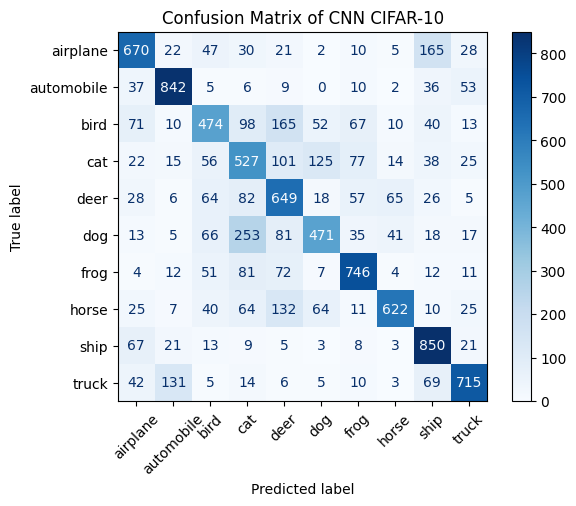

In [ ]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation = 45)
plt.title("Confusion Matrix of CNN CIFAR-10")
plt.show()


In [ ]:
# Lets to some ensembling
model1 = models.Sequential([
layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')
])


model2 = models.Sequential([
layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64, (3,3), activation='relu'),
layers.BatchNormalization(),
layers.MaxPooling2D((2,2)),
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')
])


model3 = models.Sequential([
layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
layers.MaxPooling2D((2,2)),
layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dropout(0.5),
layers.Dense(10, activation='softmax')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
for model in [model1, model2, model3]:
  model.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
  model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 80ms/step - accuracy: 0.3918 - loss: 2.8727 - val_accuracy: 0.4650 - val_loss: 1.4807
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.5397 - loss: 1.3006 - val_accuracy: 0.5334 - val_loss: 1.3260
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.6015 - loss: 1.1362 - val_accuracy: 0.5832 - val_loss: 1.2037
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.6479 - loss: 1.0087 - val_accuracy: 0.5834 - val_loss: 1.2159
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.6797 - loss: 0.9152 - val_accuracy: 0.6057 - val_loss: 1.1891
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 112ms/step - accuracy: 0.5169 - loss: 1.3833 - val_accuracy: 0.5600 - val_loss: 1.2518
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.6668 - loss: 0.9523 - val_accuracy: 0.5483 - val_loss: 1.3318
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.7333 - loss: 0.7595 - val_a

In [ ]:
pred1 = model1.predict(x_test)
pred2 = model2.predict(x_test)
pred3 = model3.predict(x_test)

ensemble_pred = (pred1 + pred2 + pred3) / 3
y_prediction = np.argmax(ensemble_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [ ]:
print("Ensemble Accuracy:", accuracy_score(y_test, y_prediction))
cm = confusion_matrix(y_test, y_prediction)

NameError: name 'y_test' is not defined